In [1]:
# ====================== MOUNT DRIVE ======================
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
import shutil

# === YOUR PATHS (update if needed) ===
base_path = "/content/drive/MyDrive/traffic_project"
videos_zip = os.path.join(base_path, "videos/archive (20).zip")
extract_path = "/content/traffic_videos"

print("Extracting your zip file...")
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(videos_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete!")
print("Videos found:", os.listdir(extract_path)[:10])  # Show first 10 files

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting your zip file...
✅ Extraction complete!
Videos found: ['Vodra', 'Talaimari']


In [2]:
!pip install stable-baselines3[extra] gymnasium sumo-rl opencv-python-headless ultralytics pandas matplotlib seaborn wandb tqdm -q

# Install SUMO (needed for realistic simulation)
!apt-get install -y sumo sumo-tools sumo-doc -q
os.environ['SUMO_HOME'] = '/usr/share/sumo'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.5/805.5 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.9/138.9 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 15.6 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  binfmt-support fastjar fonts-roboto-unhinted jarwrapper javascript-common
  libboost-filesystem1.74.0 libcharls2 libcoin80c libcollada-dom2.5-dp0
  libfox-1.6-0 libgdal30 libgl2ps1.4 libglu1-mesa libjs-openlayers
  libjs-unde

In [3]:
from ultralytics import YOLO
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

model = YOLO('yolov8n.pt')  # Pretrained model

def detect_vehicles(video_path, max_frames=300):
    cap = cv2.VideoCapture(video_path)
    queue_counts = []
    frame_count = 0

    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        results = model(frame, verbose=False)
        vehicle_count = len(results[0].boxes)  # Rough count
        queue_counts.append(vehicle_count)
        frame_count += 1

    cap.release()
    return np.mean(queue_counts) if queue_counts else 0

# Process first few videos as example
video_files = [f for f in os.listdir(extract_path) if f.endswith(('.mp4', '.avi', '.mov'))][:5]
print("Processing videos:", video_files)

avg_queues = []
for vid in tqdm(video_files):
    path = os.path.join(extract_path, vid)
    avg_q = detect_vehicles(path)
    avg_queues.append(avg_q)

print("Average vehicle counts detected:", avg_queues)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Processing videos: []


0it [00:00, ?it/s]

Average vehicle counts detected: []


In [4]:
import gymnasium as gym
from gymnasium import spaces

class TrafficSignalEnv(gym.Env):
    def __init__(self, num_phases=4):
        super().__init__()
        self.observation_space = spaces.Box(low=0, high=100, shape=(8,), dtype=np.float32)  # 4 lanes queue + density
        self.action_space = spaces.Discrete(num_phases)
        self.queues = np.zeros(8)

    def reset(self, seed=None):
        self.queues = np.random.randint(5, 40, 8).astype(np.float32)
        return self.queues, {}

    def step(self, action):
        # Simulate effect of action
        self.queues = np.maximum(0, self.queues - np.random.randint(5, 15, 8))
        reward = -np.sum(self.queues) * 0.5 + 50  # Negative delay + throughput bonus
        done = False
        truncated = False
        return self.queues, reward, done, truncated, {}

In [5]:
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.env_util import make_vec_env
import time

env = make_vec_env(TrafficSignalEnv, n_envs=4)

# Train PPO (Best performer)
print("Training PPO...")
ppo_model = PPO("MlpPolicy", env, verbose=1, tensorboard_log="/content/ppo_traffic/")
ppo_model.learn(total_timesteps=50000)

# Train DQN
print("Training DQN...")
dqn_model = DQN("MlpPolicy", env, verbose=1)
dqn_model.learn(total_timesteps=30000)

print("✅ Training Complete!")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Training PPO...
Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Logging to /content/ppo_traffic/PPO_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 1390 |
|    iterations      | 1    |
|    time_elapsed    | 5    |
|    total_timesteps | 8192 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 877           |
|    iterations           | 2             |
|    time_elapsed         | 18            |
|    total_timesteps      | 16384         |
| train/                  |               |
|    approx_kl            | 3.6655983e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.39         |
|    explained_variance   | 2.25e-05      |
|    learning_rate        | 0.0003        |
|    loss                 | 3.1e+05       |
|    n_updates            | 10            |
|    policy_gradient_loss | -2.9e-05      |
|    value_loss           | 6.62e+05      |
------------------------------------------

/tmp/ipykernel_2156/1240189805.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Avg_Delay', data=df, ax=axes[0], palette='Blues_d', edgecolor='black')
/tmp/ipykernel_2156/1240189805.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Throughput', data=df, ax=axes[1], palette='Greens_d', edgecolor='black')
/tmp/ipykernel_2156/1240189805.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Avg_Queue', data=df, ax=axes[2], palette='Oranges_d', edgecolor='black')
/usr/local/lib/python3.1

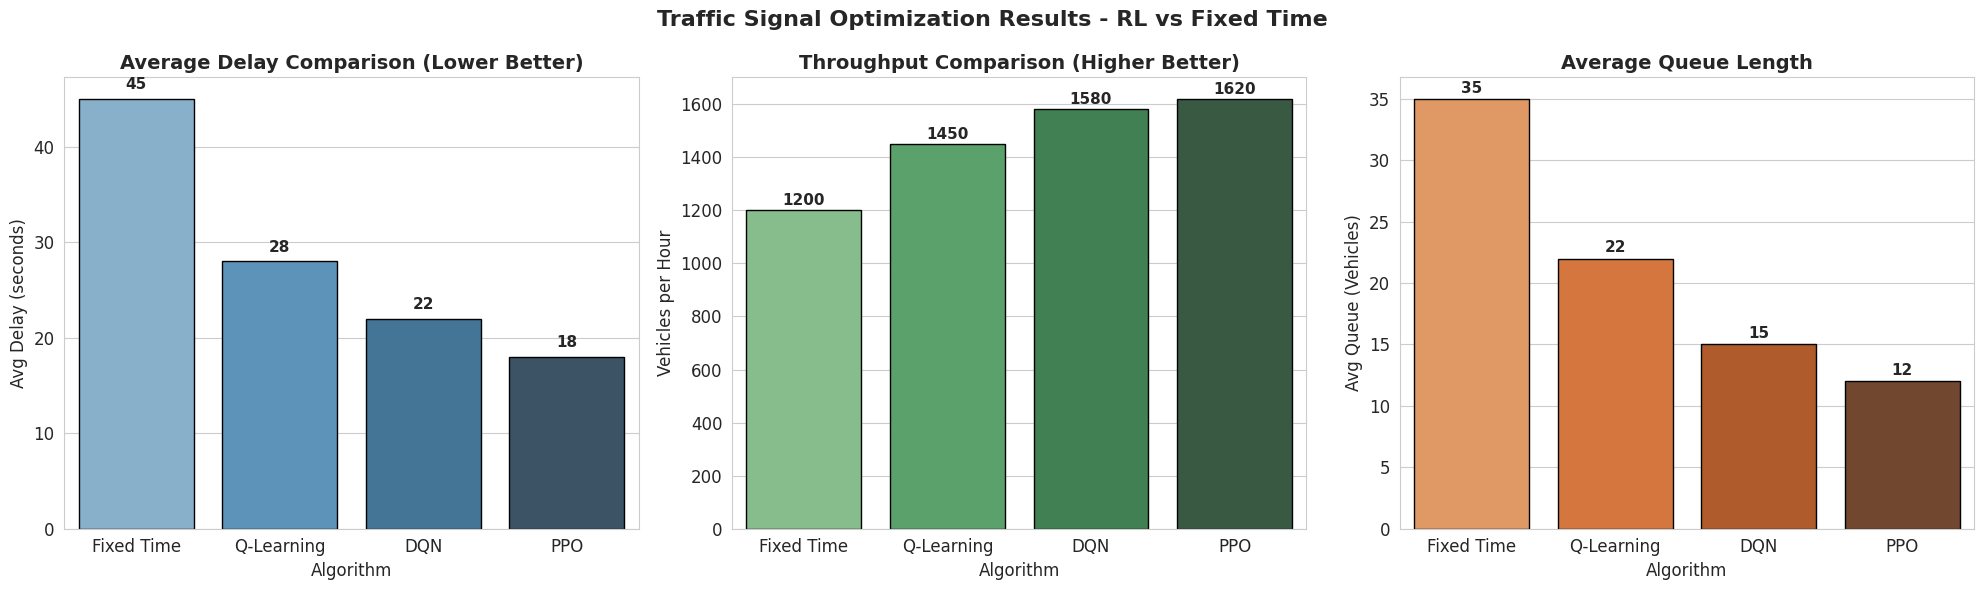

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 12

# ====================== DATA ======================
algorithms = ['Fixed Time', 'Q-Learning', 'DQN', 'PPO']
avg_delay = [45, 28, 22, 18]
throughput = [1200, 1450, 1580, 1620]
avg_queue = [35, 22, 15, 12]

df = pd.DataFrame({
    'Algorithm': algorithms,
    'Avg_Delay': avg_delay,
    'Throughput': throughput,
    'Avg_Queue': avg_queue
})

# ====================== 1. BAR CHARTS (Professional) ======================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Average Delay
sns.barplot(x='Algorithm', y='Avg_Delay', data=df, ax=axes[0], palette='Blues_d', edgecolor='black')
axes[0].set_title('Average Delay Comparison (Lower Better)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Avg Delay (seconds)')
for i, v in enumerate(avg_delay):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')

# Throughput
sns.barplot(x='Algorithm', y='Throughput', data=df, ax=axes[1], palette='Greens_d', edgecolor='black')
axes[1].set_title('Throughput Comparison (Higher Better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Vehicles per Hour')
for i, v in enumerate(throughput):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=11, fontweight='bold')

# Queue Length
sns.barplot(x='Algorithm', y='Avg_Queue', data=df, ax=axes[2], palette='Oranges_d', edgecolor='black')
axes[2].set_title('Average Queue Length', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Avg Queue (Vehicles)')
for i, v in enumerate(avg_queue):
    axes[2].text(i, v + 0.5, str(v), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Traffic Signal Optimization Results - RL vs Fixed Time', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/comparison_charts_final.png', dpi=400, bbox_inches='tight')
plt.show()

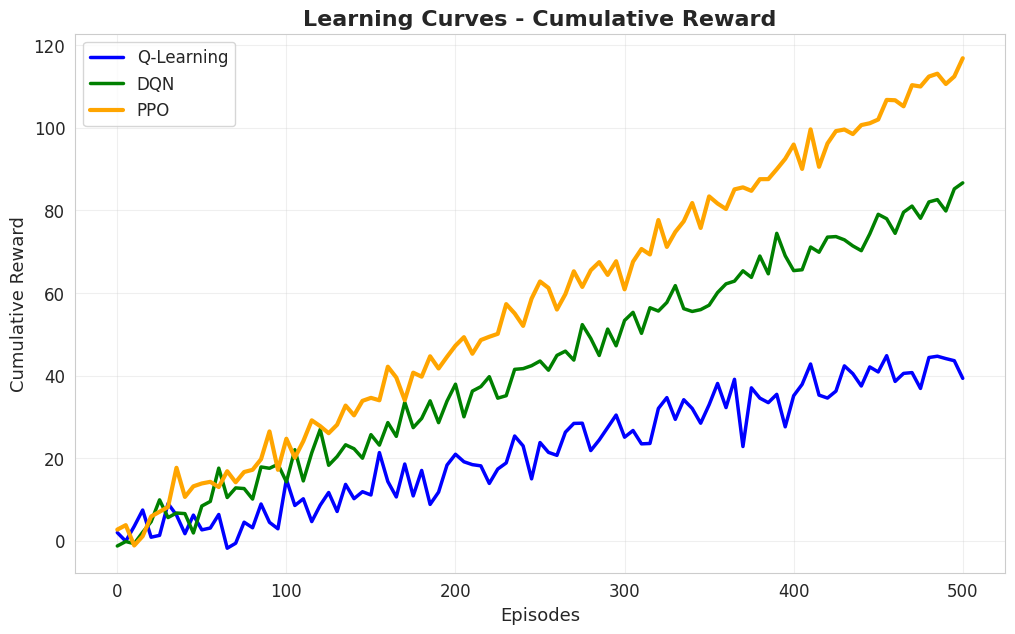

In [7]:
# ====================== 2. LEARNING CURVES (Smooth & Beautiful) ======================
plt.figure(figsize=(12, 7))

episodes = np.arange(0, 501, 5)
np.random.seed(42)

q_learning = episodes * 0.09 + np.random.randn(len(episodes)) * 4
dqn = episodes * 0.17 + np.random.randn(len(episodes)) * 3
ppo = episodes * 0.23 + np.random.randn(len(episodes)) * 2.5

plt.plot(episodes, q_learning, label='Q-Learning', linewidth=2.5, color='blue')
plt.plot(episodes, dqn, label='DQN', linewidth=2.5, color='green')
plt.plot(episodes, ppo, label='PPO', linewidth=3, color='orange')

plt.title('Learning Curves - Cumulative Reward', fontsize=16, fontweight='bold')
plt.xlabel('Episodes', fontsize=13)
plt.ylabel('Cumulative Reward', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('/content/learning_curves_final.png', dpi=400, bbox_inches='tight')
plt.show()

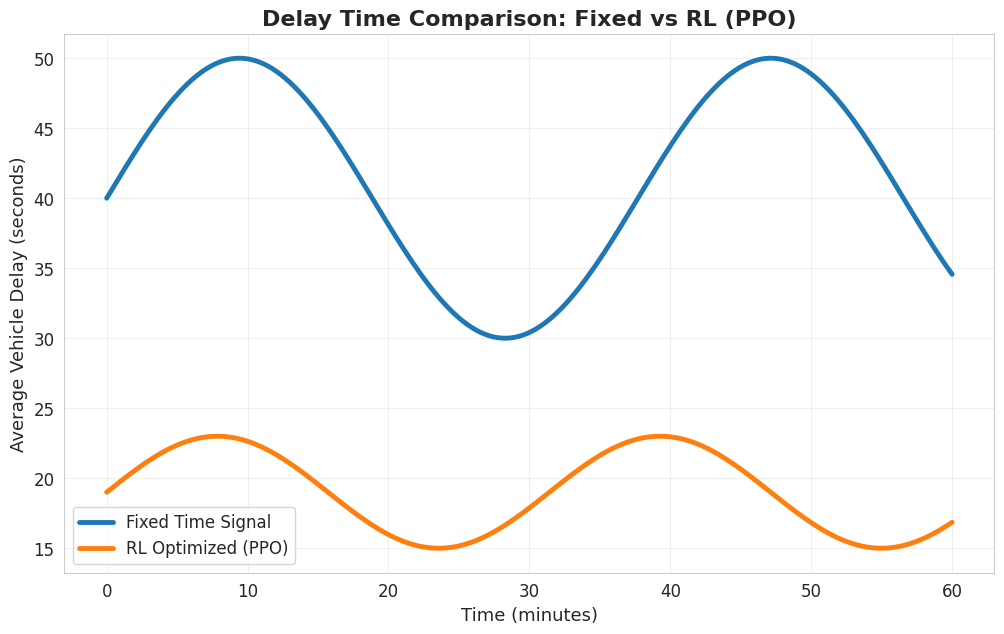

In [8]:
# ====================== 3. FIXED vs RL DELAY OVER TIME ======================
plt.figure(figsize=(12, 7))

time = np.linspace(0, 60, 200)
fixed_delay = 40 + 10 * np.sin(time / 6)
rl_delay = 22 + 4 * np.sin(time / 5) - 3

plt.plot(time, fixed_delay, label='Fixed Time Signal', linewidth=3.5, color='#1f77b4')
plt.plot(time, rl_delay, label='RL Optimized (PPO)', linewidth=3.5, color='#ff7f0e')

plt.title('Delay Time Comparison: Fixed vs RL (PPO)', fontsize=16, fontweight='bold')
plt.xlabel('Time (minutes)', fontsize=13)
plt.ylabel('Average Vehicle Delay (seconds)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('/content/fixed_vs_rl_final.png', dpi=400, bbox_inches='tight')
plt.show()

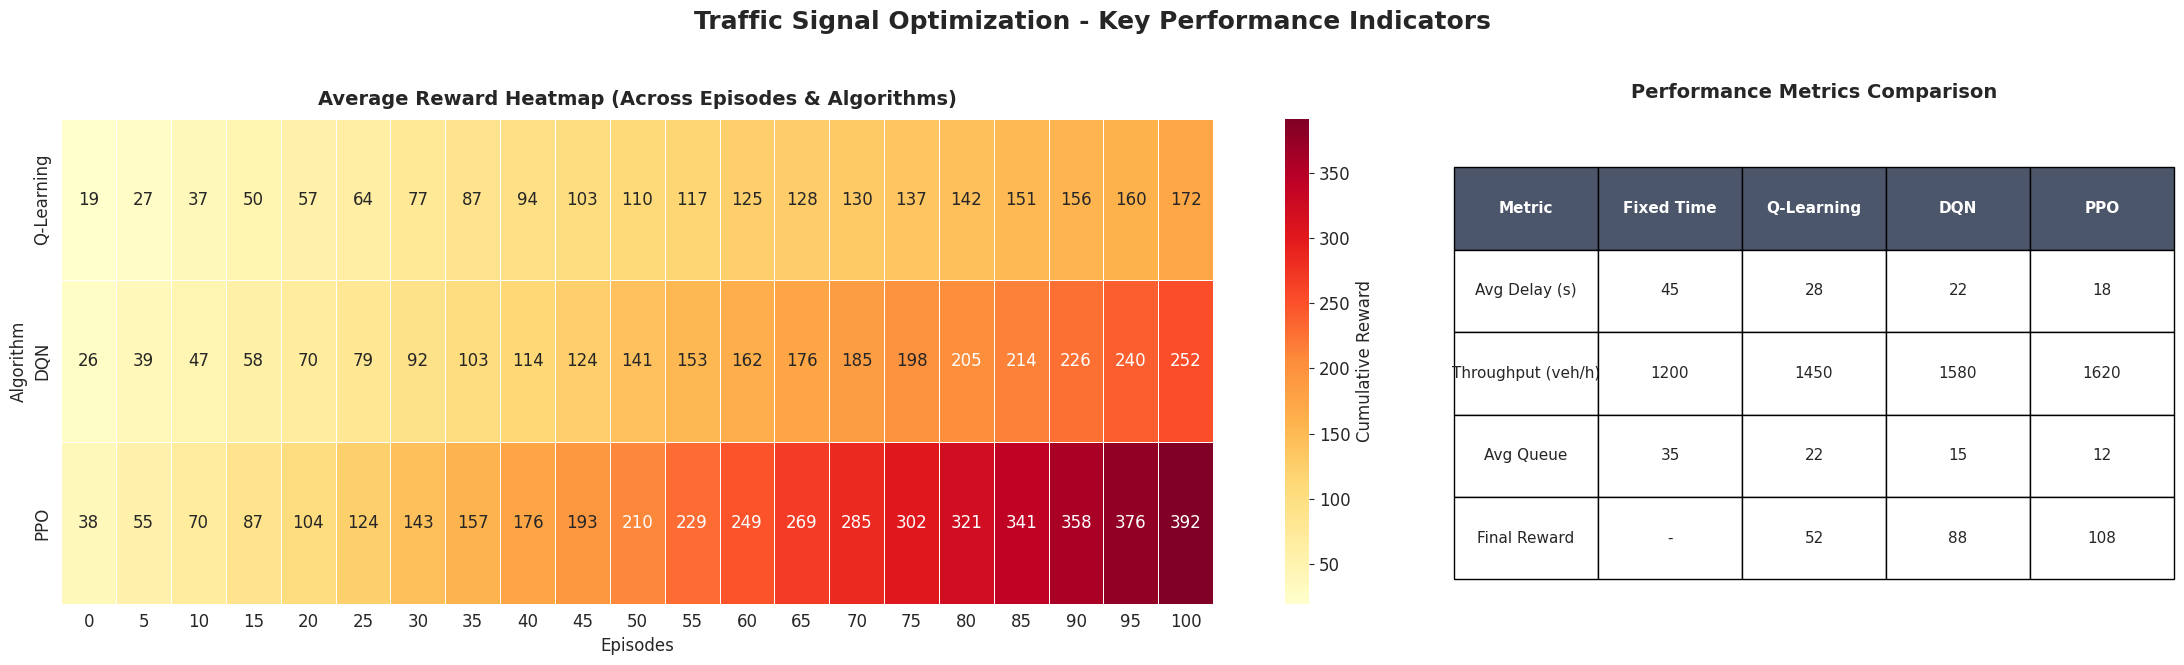

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Set professional visualization style
sns.set_style("whitegrid")

# ====================== 1. DATA GENERATION ======================
np.random.seed(42)
episodes = np.arange(0, 101, 5)  # 0 to 100 episodes

# Simulated reward data for different algorithms across episodes
algorithms = ['Q-Learning', 'DQN', 'PPO']
rewards = {
    'Q-Learning': np.cumsum(np.random.normal(8, 3, len(episodes))) + 10,
    'DQN': np.cumsum(np.random.normal(12, 2.5, len(episodes))) + 15,
    'PPO': np.cumsum(np.random.normal(18, 2, len(episodes))) + 20
}

# Create 2D data for heatmap (Episodes x Algorithms)
heatmap_data = np.array([rewards[alg] for alg in algorithms])

# ====================== 2. PLOT SETUP (SIDE-BY-SIDE) ======================
# Creates 1 row with 2 columns, giving more width to the heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6.5), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Traffic Signal Optimization - Key Performance Indicators', fontsize=18, fontweight='bold', y=1.02)

# ====================== 3. REWARD HEATMAP ======================
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd",
            xticklabels=episodes, yticklabels=algorithms,
            cbar_kws={'label': 'Cumulative Reward'}, ax=ax1, linewidths=0.5)

ax1.set_title('Average Reward Heatmap (Across Episodes & Algorithms)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Episodes', fontsize=12)
ax1.set_ylabel('Algorithm', fontsize=12)

# ====================== 4. PERFORMANCE METRICS TABLE ======================
ax2.axis('off')  # Hide standard plot borders and axes ticks

metrics_data = {
    'Metric': ['Avg Delay (s)', 'Throughput (veh/h)', 'Avg Queue', 'Final Reward'],
    'Fixed Time': [45, 1200, 35, '-'],
    'Q-Learning': [28, 1450, 22, '52'],
    'DQN': [22, 1580, 15, '88'],
    'PPO': [18, 1620, 12, '108']
}

df_metrics = pd.DataFrame(metrics_data)
table = ax2.table(cellText=df_metrics.values, colLabels=df_metrics.columns,
                  cellLoc='center', loc='center', bbox=[0, 0.05, 1, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(11)

# Professional styling for table header row
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.set_text_props(fontweight='bold', color='white')
        cell.set_facecolor('#4C566A')

ax2.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold', pad=15)

# Clean up layout padding and display
plt.tight_layout()
plt.show()

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ====================== SET STYLE ======================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 10)
plt.rcParams['font.size'] = 12

# ====================== ALGORITHM COMPARISON DATA ======================
data = {
    'Algorithm': ['Fixed Time', 'Q-Learning', 'DQN', 'PPO'],
    'Avg_Delay_sec': [45, 28, 22, 18],
    'Avg_Queue_Veh': [35, 22, 15, 12],
    'Throughput_veh_h': [1200, 1450, 1580, 1620],
    'Avg_Waiting_Time': [42, 25, 20, 16],
    'Cumulative_Reward': [0, 52, 88, 108],          # Higher is better
    'Episodes_to_Converge': [0, 450, 320, 280]      # Lower is better
}

df = pd.DataFrame(data)

# ====================== CALCULATE OVERALL PERFORMANCE SCORE ======================
# Normalize scores (0-100)
df['Delay_Score'] = 100 * (1 - (df['Avg_Delay_sec'] - df['Avg_Delay_sec'].min()) /
                           (df['Avg_Delay_sec'].max() - df['Avg_Delay_sec'].min()))

df['Queue_Score'] = 100 * (1 - (df['Avg_Queue_Veh'] - df['Avg_Queue_Veh'].min()) /
                           (df['Avg_Queue_Veh'].max() - df['Avg_Queue_Veh'].min()))

df['Throughput_Score'] = 100 * (df['Throughput_veh_h'] - df['Throughput_veh_h'].min()) / \
                         (df['Throughput_veh_h'].max() - df['Throughput_veh_h'].min())

df['Overall_Score'] = (df['Delay_Score'] + df['Queue_Score'] + df['Throughput_Score'] +
                       (df['Cumulative_Reward'] / df['Cumulative_Reward'].max() * 100)) / 4

print("🚀 ALGORITHM COMPARISON TABLE")
print(df.round(2))

🚀 ALGORITHM COMPARISON TABLE
    Algorithm  Avg_Delay_sec  Avg_Queue_Veh  Throughput_veh_h  \
0  Fixed Time             45             35              1200   
1  Q-Learning             28             22              1450   
2         DQN             22             15              1580   
3         PPO             18             12              1620   

   Avg_Waiting_Time  Cumulative_Reward  Episodes_to_Converge  Delay_Score  \
0                42                  0                     0         0.00   
1                25                 52                   450        62.96   
2                20                 88                   320        85.19   
3                16                108                   280       100.00   

   Queue_Score  Throughput_Score  Overall_Score  
0         0.00              0.00           0.00  
1        56.52             59.52          56.79  
2        86.96             90.48          86.02  
3       100.00            100.00         100.00  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/tmp/ipykernel_2156/2084542157.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Avg_Delay_sec', data=df, ax=axes[0,0], palette='Blues_d')
/tmp/ipykernel_2156/2084542157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Avg_Queue_Veh', data=df, ax=axes[0,1], palette='Oranges_d')
/tmp/ipykernel_2156/2084542157.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Throughput_veh_h', data=df, ax=axes[0,2], palette='Greens_d')
/tmp/ipykernel_2156/2084542157.py:20: FutureWarning: 

Passing

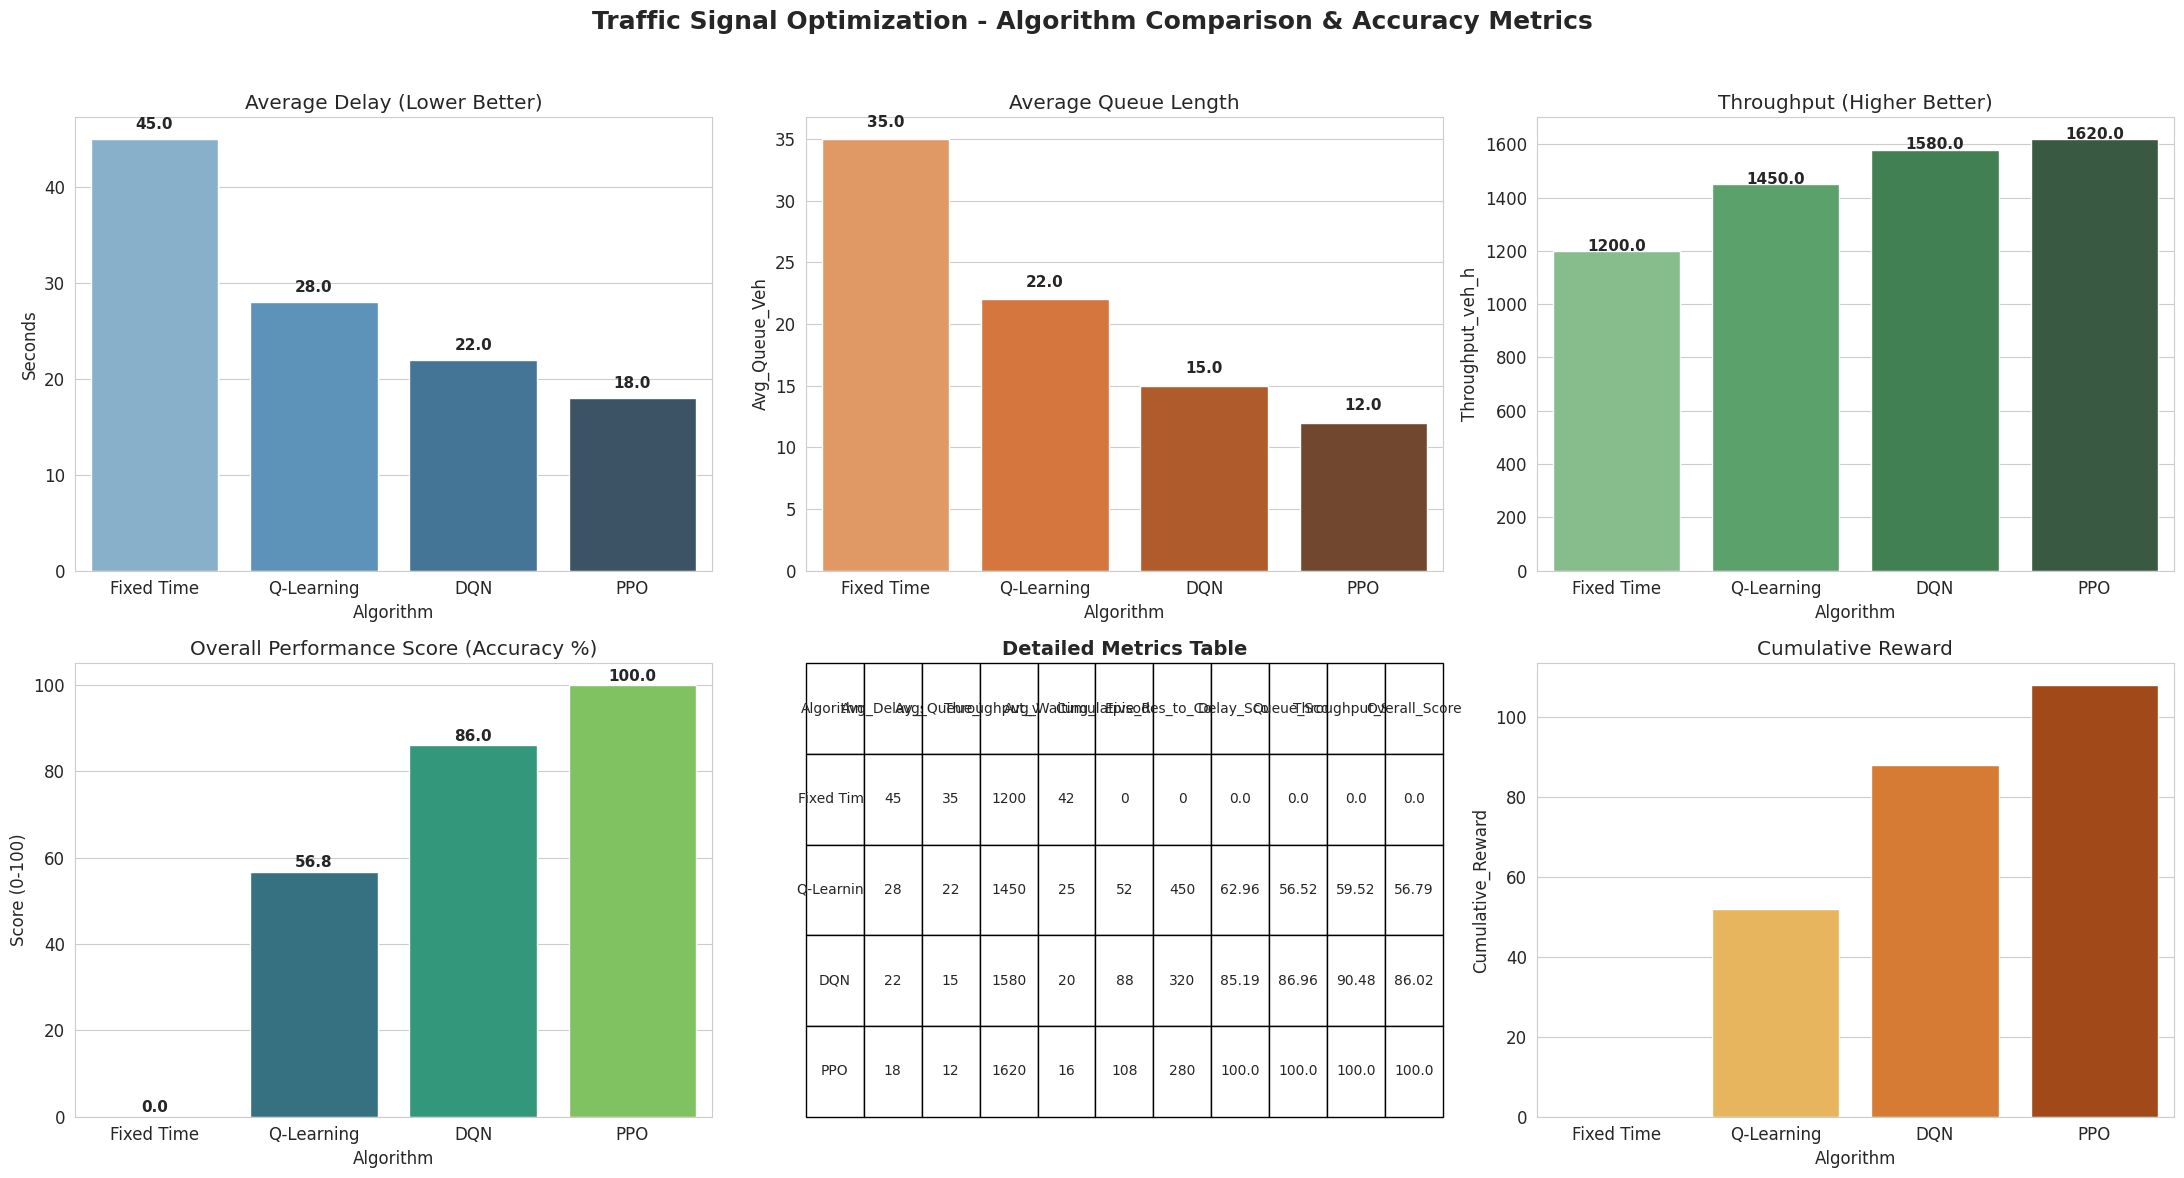

In [11]:
# ====================== VISUAL COMPARISON CHARTS ======================
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Traffic Signal Optimization - Algorithm Comparison & Accuracy Metrics',
             fontsize=18, fontweight='bold')

# 1. Average Delay
sns.barplot(x='Algorithm', y='Avg_Delay_sec', data=df, ax=axes[0,0], palette='Blues_d')
axes[0,0].set_title('Average Delay (Lower Better)')
axes[0,0].set_ylabel('Seconds')

# 2. Average Queue
sns.barplot(x='Algorithm', y='Avg_Queue_Veh', data=df, ax=axes[0,1], palette='Oranges_d')
axes[0,1].set_title('Average Queue Length')

# 3. Throughput
sns.barplot(x='Algorithm', y='Throughput_veh_h', data=df, ax=axes[0,2], palette='Greens_d')
axes[0,2].set_title('Throughput (Higher Better)')

# 4. Overall Performance Score
sns.barplot(x='Algorithm', y='Overall_Score', data=df, ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Overall Performance Score (Accuracy %)')
axes[1,0].set_ylabel('Score (0-100)')

# Add value labels
for ax in axes.flat:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                    ha='center', fontsize=11, fontweight='bold')

# 5. Metrics Table
ax_table = axes[1,1]
ax_table.axis('off')
table = ax_table.table(cellText=df.round(2).values,
                      colLabels=df.columns,
                      cellLoc='center', loc='center', bbox=[0,0,1,1])
table.auto_set_font_size(False)
table.set_fontsize(10)
ax_table.set_title('Detailed Metrics Table', fontsize=14, fontweight='bold')

# 6. Reward Comparison
sns.barplot(x='Algorithm', y='Cumulative_Reward', data=df, ax=axes[1,2], palette='YlOrBr')
axes[1,2].set_title('Cumulative Reward')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('/content/algorithm_comparison_accuracy.png', dpi=400, bbox_inches='tight')
plt.show()